In [6]:
"""
Module for determining UV luminosities and the UV luminosity function
for Lyman Break Galaxy (LBG) candidates selected via the z-dropout 
technique in the VIK J2348-3054 field at z ~ 6.9.

LBGs are selected by detecting a break between the z-band and Y-band,
with non-detection in the i-band. UV luminosity is estimated from the
Y-band flux, which probes the rest-frame UV continuum (~1450 AA) at z~6.9.
"""

import numpy as np
import matplotlib.pyplot as plt
from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import astropy.units as u
import astropy.constants as const
from scipy import special
from scipy.optimize import curve_fit
from synphot import SpectralElement

# -----------------------------------------------------------------------
# Cosmology  (same as Lambert et al. 2024)
# -----------------------------------------------------------------------
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)

# -----------------------------------------------------------------------
# Survey parameters
# -----------------------------------------------------------------------
QSO_REDSHIFT    = 6.9018

# LBGs at z~6.9 are selected over a broader dz than LAEs.
# The Y-band (lambda_c ~ 9900 AA, FWHM ~ 1000 AA) corresponds to
# rest-frame wavelengths ~ 1260-1390 AA at z=6.9, giving dz ~ 0.8.
Z_MIN = 6.5   # conservative lower bound for LBG selection window
Z_MAX = 7.3   # conservative upper bound

# Survey area after trimming (this work)
AREA_DEG2       = 3.1 * u.deg**2
SQUARE_DEG_IN_SR = 41252.96 * u.deg**2

# Effective comoving volume of the survey
full_volume     = COSMO.comoving_volume(Z_MAX) - COSMO.comoving_volume(Z_MIN)
effective_volume = full_volume * (AREA_DEG2 / SQUARE_DEG_IN_SR)

# Rest-frame wavelength probed by Y-band at z=6.9 (AA)
# Y-band central wavelength ~ 9900 AA  =>  9900/(1+6.9) ~ 1254 AA
# We reference to 1500 AA (standard M_UV definition) via a k-correction
REST_WAVE_YBAND  = 9900.0 / (1.0 + QSO_REDSHIFT)   # ~ 1254 AA
UV_REF_WAVE      = 1500.0                            # AA  (standard M_UV)


# -----------------------------------------------------------------------
# Completeness function  (fit to fake-source recovery, same form as
# Lambert et al. 2024 -- replace popt values after running your own
# completeness simulations with the Y-band image)
# -----------------------------------------------------------------------
def _erf_model(x, a, b, z0, f):
    """Error-function model used to fit the completeness curve."""
    return a * special.erf(f * (x - z0)) + b

# Placeholder parameters -- REPLACE with your own curve_fit results
# from the fake-source injection test (see completeness module below)
COMPLETENESS_POPT = [-0.43, 0.478, 24.5, 2.22]

def completeness(y_mag: float) -> float:
    """
    Returns the detection completeness (0-1) for a given Y-band magnitude.
    Based on fake-source injection/recovery tests in the Y-band image.
    """
    return _erf_model(y_mag, *COMPLETENESS_POPT)


# -----------------------------------------------------------------------
# Magnitude <-> flux conversion helpers
# -----------------------------------------------------------------------
def mag_to_fnu(mag: float) -> u.Quantity:
    """
    Convert AB magnitude to flux density f_nu  [erg/s/cm^2/Hz].
    AB zero-point: m_AB = -2.5 log10(f_nu) - 48.6
    """
    return (10.0 ** ((mag + 48.6) / (-2.5))
            * u.erg / u.s / u.cm**2 / u.Hz)

def fnu_err_from_mag_err(mag: float, mag_err: float) -> u.Quantity:
    """Propagate magnitude uncertainty to f_nu uncertainty."""
    fnu    = mag_to_fnu(mag)
    factor = np.log(10) / 2.5
    return factor * fnu * mag_err


# -----------------------------------------------------------------------
# UV absolute magnitude  M_UV
# -----------------------------------------------------------------------
def compute_m_uv(y_mag: float, redshift: float = QSO_REDSHIFT) -> float:
    """
    Compute rest-frame UV absolute magnitude M_UV (referenced to 1500 AA)
    from the observed Y-band AB magnitude.

    Steps
    -----
    1.  Convert Y-band magnitude to apparent magnitude at rest-frame
        ~1254 AA (the wavelength actually sampled by the Y-band at z~6.9).
    2.  Apply a small k-correction to reference to 1500 AA assuming a
        power-law UV continuum  f_lambda ~ lambda^beta  with beta = -2.0
        (typical for z~7 LBGs; Bouwens et al. 2014).
    3.  Convert to absolute magnitude using the luminosity distance.
    """
    BETA = -2.0   # UV continuum slope
    # k-correction: delta_m = -2.5*(beta+2)*log10(lambda_obs/lambda_ref)
    # For beta = -2  this term is zero; we keep it for generality.
    k_corr = -2.5 * (BETA + 2.0) * np.log10(REST_WAVE_YBAND / UV_REF_WAVE)

    # Distance modulus
    lum_dist     = COSMO.luminosity_distance(redshift).to(u.pc)
    dist_modulus = 5.0 * np.log10(lum_dist.value) - 5.0

    # M_UV  (the -2.5*log10(1+z) term accounts for the bandwidth compression)
    m_uv = y_mag - dist_modulus - k_corr 
    return m_uv


def compute_l_uv(m_uv: float) -> u.Quantity:
    """
    Convert M_UV to UV luminosity L_UV  [erg/s/Hz]  using the standard
    absolute-magnitude to luminosity conversion.
    L_nu = 10^( (M_UV - 51.6) / (-2.5) )  erg/s/Hz
    (where 51.6 arises from the AB zero-point and 10 pc reference distance)
    """
    return (10.0 ** ((m_uv - 51.6) / (-2.5))
            * u.erg / u.s / u.Hz)


# -----------------------------------------------------------------------
# Star formation rate from UV luminosity
# Using the Kennicutt & Evans (2012) calibration for a Chabrier IMF.
# SFR [M_sun/yr] = L_UV [erg/s/Hz] / (8.0e27 erg/s/Hz per M_sun/yr)
# See also Madau & Dickinson (2014).
# -----------------------------------------------------------------------
UV_SFR_CALIBRATION = 8.0e27  # erg/s/Hz  per  M_sun/yr

def compute_sfr_uv(l_uv: u.Quantity) -> u.Quantity:
    """
    UV-based star formation rate  [M_sun/yr].
    Note: this is a lower limit because it does not account for
    dust-obscured star formation.
    """
    sfr = l_uv.to(u.erg / u.s / u.Hz).value / UV_SFR_CALIBRATION
    return sfr * u.solMass / u.yr


# -----------------------------------------------------------------------
# Schechter luminosity function  (in M_UV space)
# Phi*(M) dM = (ln10/2.5) * Phi* * 10^[-0.4*(M-M*)(alpha+1)]
#            * exp(-10^[-0.4*(M-M*)])  dM
# -----------------------------------------------------------------------
def schechter_muv(m_uv, log_phi_star, m_star, alpha):
    """
    UV luminosity function in magnitude units (Schechter 1976).

    Parameters
    ----------
    m_uv        : array-like   absolute UV magnitudes
    log_phi_star: float        log10 of normalisation [Mpc^-3 mag^-1]
    m_star      : float        characteristic magnitude
    alpha       : float        faint-end slope

    Returns
    -------
    phi  [Mpc^-3 mag^-1]
    """
    phi_star = 10.0 ** log_phi_star
    x        = 10.0 ** (-0.4 * (m_uv - m_star))
    return (np.log(10.0) / 2.5) * phi_star * x ** (alpha + 1.0) * np.exp(-x)

# -----------------------------------------------------------------------
# Reference LF parameters from Bouwens et al. (2021) at z~7
# These are the blank-field values we compare against to measure overdensity
# -----------------------------------------------------------------------
# log_phi_star = -3.49,  M_star = -20.88,  alpha = -1.87  (Bouwens+2021)
BOUWENS21_PARAMS = (-3.49, -20.88, -1.87)


def scaled_schechter_muv(m_uv, offset):
    """
    Schechter function with a free amplitude scaling factor (offset)
    applied to the Bouwens et al. (2021) shape.  Used for fitting
    the overdensity factor delta = offset - 1.
    """
    return offset * schechter_muv(m_uv, *BOUWENS21_PARAMS)


# -----------------------------------------------------------------------
# Main analysis
# -----------------------------------------------------------------------
if __name__ == '__main__':

    # ------------------------------------------------------------------
    # 1.  Load candidate catalogue
    #     Expected columns: RA, Dec, i_mag, i_err, z_mag, z_err,
    #                       y_mag, y_err
    # ------------------------------------------------------------------
    CANDIDATES_FILE = '/Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat'

    data = np.genfromtxt(
    CANDIDATES_FILE,
    names=True,
    dtype=None,
    encoding=None
)

    ra    = data['RA']
    dec   = data['DEC']
    y_mag = data['Y_mag']
    y_err = data['Y_err']
    z_mag = data['Z_mag']
    z_err = data['Z_err']
    i_mag = data['I_mag']
    i_err = data['I_err']
    # ------------------------------------------------------------------
    # 2.  Compute M_UV, L_UV, and SFR for each candidate
    # ------------------------------------------------------------------
    m_uv_arr = np.array([compute_m_uv(ym) for ym in y_mag])
    l_uv_arr = np.array([compute_l_uv(m).value for m in m_uv_arr]) * u.erg/u.s/u.Hz
    sfr_arr  = np.array([compute_sfr_uv(l).value for l in l_uv_arr])

    # Magnitude uncertainty propagated to M_UV  (distance and k-corr are exact)
    m_uv_err = y_err   # same uncertainty in magnitudes

    print(f'\nM_UV range : {m_uv_arr.min():.2f}  to  {m_uv_arr.max():.2f}')
    print(f'SFR range  : {sfr_arr.min():.2f}  to  {sfr_arr.max():.2f}  M_sun/yr')

    # ------------------------------------------------------------------
    # 3.  Build the UV luminosity function
    # ------------------------------------------------------------------
    BIN_WIDTH = 0.5      # magnitudes  (wider than LAE LF because LBG
                         # numbers are modest)
    M_MIN     = -23.0
    M_MAX     = -18.0
    bins      = np.arange(M_MIN, M_MAX + BIN_WIDTH, BIN_WIDTH)
    bin_centres = 0.5 * (bins[:-1] + bins[1:])

    counts, _ = np.histogram(m_uv_arr, bins=bins)
    count_err = np.sqrt(counts)   # Poisson

    # Completeness at the Y-band magnitude corresponding to each bin centre
    # We convert M_UV bin centre back to approximate Y-band magnitude for
    # the completeness lookup (inverse of compute_m_uv at z=QSO_REDSHIFT)
    lum_dist     = COSMO.luminosity_distance(QSO_REDSHIFT).to(u.pc)
    dist_modulus = 5.0 * np.log10(lum_dist.value) - 5.0
    y_mag_bins   = bin_centres + dist_modulus + 2.5 * np.log10(1.0 + QSO_REDSHIFT)

    comp_frac = np.array([completeness(ym) for ym in y_mag_bins])
    comp_frac = np.clip(comp_frac, 0.05, 1.0)   # avoid division by near-zero

    # Volume element  [Mpc^3 mag^-1]
    vol_per_bin = effective_volume.to(u.Mpc**3).value * BIN_WIDTH

    # Luminosity function  Phi  [Mpc^-3 mag^-1]
    good        = counts > 0
    phi         = counts / (vol_per_bin * comp_frac)
    phi_err     = count_err / (vol_per_bin * comp_frac)

    log_phi     = np.where(good, np.log10(phi),     np.nan)
    log_phi_err = np.where(good, phi_err / (np.log(10) * phi), np.nan)

    # ------------------------------------------------------------------
    # 4.  Fit the overdensity factor relative to Bouwens et al. (2021)
    # ------------------------------------------------------------------
    fit_mask = good & (bin_centres < -19.0)   # avoid very faint/incomplete bins

    popt, pcov = curve_fit(
        scaled_schechter_muv,
        bin_centres[fit_mask],
        phi[fit_mask],
        p0=1.0,
        sigma=phi_err[fit_mask],
        absolute_sigma=True,
        maxfev=5000
    )
    offset      = popt[0]
    offset_err  = np.sqrt(pcov[0, 0])
    delta       = offset - 1.0     # overdensity factor  (delta=0 => field density)

    print(f'\nOverdensity factor  offset = {offset:.2f} +/- {offset_err:.2f}')
    print(f'delta (offset - 1)         = {delta:.2f}')

    # ------------------------------------------------------------------
    # 5.  Save results
    # ------------------------------------------------------------------
    OUTFILE = 'lbg_luminosity_function.txt'
    header  = ('M_UV_centre   N_counts   log_phi   log_phi_err   '
               'completeness   y_mag_approx')
    np.savetxt(
        OUTFILE,
        np.column_stack([
            bin_centres, counts, log_phi, log_phi_err,
            comp_frac, y_mag_bins
        ]),
        header=header,
        fmt='%10.4f'
    )
    print(f'\nLuminosity function saved to {OUTFILE}')

    # ------------------------------------------------------------------
    # 6.  Plot
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(7, 5))

    # Reference Bouwens+2021 LF
    m_ref   = np.linspace(M_MIN, M_MAX, 300)
    phi_ref = schechter_muv(m_ref, *BOUWENS21_PARAMS)
    ax.plot(m_ref, np.log10(phi_ref),
            color='steelblue', ls='--', lw=1.5,
            label=r'Bouwens et al. (2021), $z\sim7$')

    # Scaled (best-fit overdensity) LF
    ax.plot(m_ref, np.log10(scaled_schechter_muv(m_ref, offset)),
            color='k', ls='-', lw=1.5,
            label=rf'Scaled LF ($\times${offset:.1f})')

    # Data points (this work)
    ax.errorbar(
        bin_centres[good], log_phi[good], yerr=log_phi_err[good],
        fmt='ko', ms=5, capsize=3,
        label='This work (LBG candidates)'
    )

    # Upper limits for empty bins
    empty = (~good) & (bin_centres > M_MIN + BIN_WIDTH) & (bin_centres < -19.0)
    upper_limit = 1.846 / (vol_per_bin * comp_frac)   # 1-sigma Poisson upper limit
    ax.quiver(
        bin_centres[empty],
        np.log10(upper_limit[empty]),
        np.zeros(empty.sum()),
        -0.3 * np.ones(empty.sum()),
        color='k', width=0.003
    )

    ax.set_xlabel(r'$M_\mathrm{UV}$', fontsize=13)
    ax.set_ylabel(
        r'$\log_{10}\,\Phi\;[\mathrm{Mpc}^{-3}\,\mathrm{mag}^{-1}]$',
        fontsize=13
    )
    ax.set_xlim(M_MIN, M_MAX)
    ax.set_ylim(-7.0, -2.0)
    ax.invert_xaxis()    # brighter (more negative) magnitudes on the left
    ax.legend(frameon=False, fontsize=10)
    ax.set_title(
        r'UV LF around VIK~J2348$-$3054 ($z=6.9$)',
        fontsize=11
    )
    plt.tight_layout()
    plt.savefig('plots/lbg_luminosity_function.png', dpi=150)
    plt.show()


M_UV range : -28.10  to  -24.33
SFR range  : 294.29  to  9522.16  M_sun/yr


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_89364/3481208469.py:263: RuntimeWarning: divide by zero encountered in log10
  log_phi     = np.where(good, np.log10(phi),     np.nan)
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_89364/3481208469.py:264: RuntimeWarning: invalid value encountered in divide
  log_phi_err = np.where(good, phi_err / (np.log(10) * phi), np.nan)


ValueError: `ydata` must not be empty!

In [15]:
with open('/Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat') as f:
    for i in range(10):
        print(f.readline())

RA DEC Y_mag Y_err Z_mag Z_err Z_SNR I_mag I_err I_SNR Z-Y I-Z I_detected

357.4598447 -31.6293885 24.7174 0.240417491044225 25.539699999999996 0.21283044894939257 5.101413872487291 27.46 inf 0.0 0.8222999999999949 1.9203000000000046 False

357.2786305 -31.6607243 23.8948 0.13713066761304707 25.4245 0.20493162274280657 5.298041318497491 27.46 inf 0.0 1.5296999999999983 2.0355000000000025 False

356.413995 -31.5648471 24.0791 0.14442911756290697 24.9959 0.14044614626254434 7.7306229729400915 27.46 inf 0.0 0.9167999999999985 2.464100000000002 False

356.1709289 -31.3175115 23.863300000000002 0.12573344821486446 25.159699999999997 0.16383955566345998 6.626825862420682 27.46 inf 0.0 1.296399999999995 2.3003000000000036 False

356.8379135 -31.5857589 24.607300000000002 0.22981829779197305 25.5503 0.22522877258467666 4.820592823458813 27.46 inf 0.0 0.9429999999999978 1.9097000000000008 False

356.8605908 -31.5902002 23.255000000000003 0.08624876810714459 24.110699999999998 0.0658984066575209


M_UV range : -28.10  to  -24.33
SFR range  : 294.29  to  9522.16  M_sun/yr

Counts per bin: [ 0  0  1  0  0  0  2  5 12 69 22  0]

Overdensity factor ≈ 1.00


/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_89364/3617694142.py:145: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(
/var/folders/9v/db3j63px68q3f33kdb7_7wbc0000gn/T/ipykernel_89364/3617694142.py:165: RuntimeWarning: divide by zero encountered in log10
  ax.plot(m_ref, np.log10(phi_ref), '--', label='Field LF (z~7)')


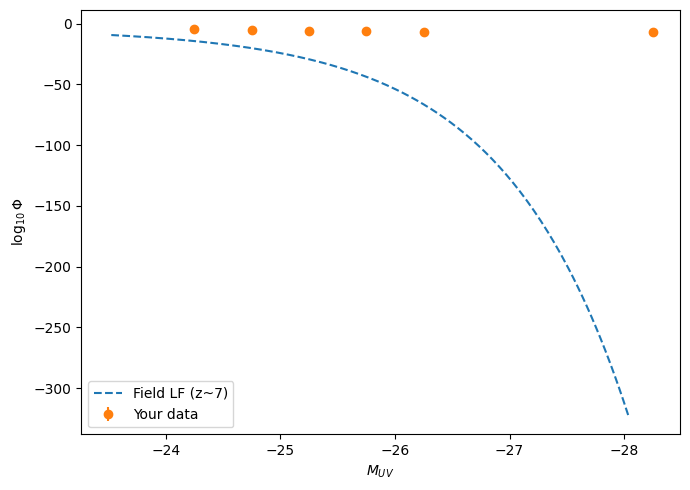

In [ ]:
"""
This module computes the UV luminosity function for Lyman Break Galaxies (LBGs)
using z-band magnitudes (rest-frame ~1700 Å).

Key changes from LAE version:
- Removed Lyα flux computation (no narrowband needed)
- Removed filter transmission physics (synphot not required)
- Convert z-band magnitude directly to M_UV
- Luminosity function computed in magnitude space
"""

import numpy as np
import pylab as plt

from astropy.cosmology import FlatLambdaCDM
from astropy.coordinates import SkyCoord
import astropy.units as u

from scipy import special
from scipy.optimize import curve_fit

from zero_points_cdfs import zero_points_cdfs
from plotting import start_plot, end_plot


# ============================================================
# Completeness function (unchanged)
# ============================================================
def func(x, a, b, z, f):
    return a * special.erf(f * (x - z)) + b

completeness_popt = [
    -0.43237270715294684,
    0.4782243532927713,
    24.045316225218553,
    2.2224473398288085
]

def complete(mag):
    return func(mag, *completeness_popt)


# ============================================================
# Cosmology and constants
# ============================================================
COSMO = FlatLambdaCDM(H0=70, Om0=0.3)

Z_REDSHIFT = 4.601
DL = 42305.5  # luminosity distance in Mpc (from paper)
K_CORRECTION = 0.022

V_eff = 20638.77  # comoving volume in Mpc^3 (from paper)


# ============================================================
# Convert apparent magnitude to absolute magnitude
# ============================================================
def apparent_to_absolute_mag(m_z):
    """
    Converts z-band apparent magnitude to rest-frame M_1700 Å
    """
    return (
        m_z
        + 2.5 * np.log10(1 + Z_REDSHIFT)
        - 5 * np.log10(DL)
        + 5
        - K_CORRECTION
    )


# ============================================================
# Schechter function in magnitude form
# ============================================================
def schechter_M(M, phi_star, M_star, alpha):
    return (
        0.4 * np.log(10) * phi_star *
        (10**(0.4 * (M_star - M)))**(alpha + 1) *
        np.exp(-10**(0.4 * (M_star - M)))
    )


# ============================================================
# MAIN
# ============================================================
if __name__ == '__main__':

    Z_CATALOG = '../correct_stacks/N964/z.cat'
    CANDIDATES_CATALOG = 'candidates_e.txt'

    # Load catalog data
    ra_z, dec_z, z_mag, z_err = np.loadtxt(
        Z_CATALOG, unpack=True, usecols=(0, 1, 4, 5)
    )

    ra_cand, dec_cand = np.loadtxt(CANDIDATES_CATALOG, unpack=True)

    candidates = SkyCoord(ra=ra_cand * u.deg, dec=dec_cand * u.deg)
    z_catalog = SkyCoord(ra=ra_z * u.deg, dec=dec_z * u.deg)

    idx, _, _ = candidates.match_to_catalog_sky(z_catalog)

    # Apply zeropoint correction
    z_mag = z_mag[idx] + zero_points_cdfs.z_band.mag_correct(1)
    z_err = z_err[idx]

    # Convert to absolute magnitude
    M_uv = apparent_to_absolute_mag(z_mag)

    print("Number of objects:", len(M_uv))
    print("M_UV range:", np.min(M_uv), "to", np.max(M_uv))

    # Binning
    binwidth = 0.5
    bins = np.arange(-24.5, -18.0, binwidth)

    counts, edges = np.histogram(M_uv, bins=bins)
    centers = 0.5 * (edges[:-1] + edges[1:])

    # Compute luminosity function
    phi = np.zeros_like(centers, dtype=float)
    phi_err = np.zeros_like(centers, dtype=float)

    for i in range(len(centers)):
        in_bin = (M_uv >= edges[i]) & (M_uv < edges[i+1])

        if np.sum(in_bin) > 0:
            weights = 1.0 / complete(z_mag[in_bin])
            phi[i] = np.sum(weights) / (V_eff * binwidth)
            phi_err[i] = np.sqrt(np.sum(weights**2)) / (V_eff * binwidth)

    # Convert to log space
    valid = phi > 0

    centers = centers[valid]
    phi = phi[valid]
    phi_err = phi_err[valid]

    phi_log = np.log10(phi)
    phi_err_log = (1.0 / np.log(10)) * (phi_err / phi)

    print("Space density (log):", phi_log)
    print("Errors:", phi_err_log)

    # Fit Schechter function
    p0 = [1e-3, -21.0, -1.7]

    popt, pcov = curve_fit(
        schechter_M,
        centers,
        phi,
        p0=p0,
        maxfev=5000
    )

    # Plot
    start_plot(r'$M_{UV}$', r'$\log \Phi$ [Mpc$^{-3}$ mag$^{-1}$]')

    plt.errorbar(
        centers,
        phi_log,
        yerr=phi_err_log,
        color='k',
        fmt='o',
        label='This work',
        ms=4
    )

    M_plot = np.linspace(-24.5, -18.0, 200)

    plt.plot(
        M_plot,
        np.log10(schechter_M(M_plot, *popt)),
        color='r',
        linestyle='--',
        label='Schechter fit'
    )

    plt.gca().invert_xaxis()

    plt.xlim(-24.5, -18.0)
    plt.ylim(-6.5, -2.0)

    plt.legend(frameon=False)

    end_plot('plots/lbg_uv_luminosity_function.png')
    plt.show()

In [8]:
print("Number of objects:", len(m_uv_arr))

Number of objects: 111


Luminosity distance : 42305.5 Mpc
Effective volume    : 53647.13 Mpc^3
Total LBG candidates loaded: 111
z_mag range : 22.45 to 25.79
M1700 range : -23.84 to -20.50

M1700 bin   log(phi)   log(phi_err)
  -23.75      -4.388       0.395
  -22.75      -4.297       0.321
  -22.25      -3.614       0.094
  -21.75      -2.910       0.026
  -21.25      -1.738       0.004
  -20.75      -1.198       0.002
  -20.25      -2.789       0.014

Overdensity factor δ = 4.45 +/- 0.08
Saved: plots/lbg_luminosity_function.png


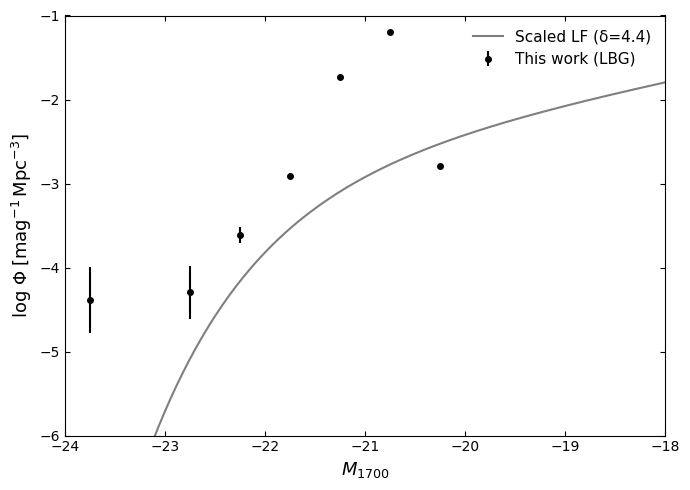

In [14]:
"""
LBG UV luminosity function from pre-selected candidate catalog.
Dependencies: numpy, matplotlib only.
"""

import numpy as np
import matplotlib.pyplot as plt


# ── Cosmology ─────────────────────────────────────────────────────────────────
H0    = 70.0
Om0   = 0.3
Ol0   = 1.0 - Om0
C_KMS = 299792.458

def comoving_distance(z, n_steps=10000):
    z_arr = np.linspace(0, z, n_steps)
    E_z   = np.sqrt(Om0 * (1 + z_arr)**3 + Ol0)
    return (C_KMS / H0) * np.trapezoid(1.0 / E_z, z_arr)

def comoving_volume(z):
    dc = comoving_distance(z)
    return (4.0 / 3.0) * np.pi * dc**3

def luminosity_distance(z):
    return (1 + z) * comoving_distance(z)


# ── Survey parameters ─────────────────────────────────────────────────────────
LBG_REDSHIFT   = 4.601
ZMIN, ZMAX     = 4.2, 5.0
AREA_ARCMIN2   = 23.7
ARCMIN2_PER_SR = (180.0 * 60.0 / np.pi)**2
SKY_FRACTION   = AREA_ARCMIN2 / (4 * np.pi * ARCMIN2_PER_SR)

effective_volume = (comoving_volume(ZMAX) - comoving_volume(ZMIN)) * SKY_FRACTION
LUM_DIST_MPC     = luminosity_distance(LBG_REDSHIFT)
LUM_DIST_PC      = LUM_DIST_MPC * 1e6      # ← convert to parsecs for distance modulus

K_CORR_1700 =  0.022
K_CORR_1500 = -0.015

print(f'Luminosity distance : {LUM_DIST_MPC:.1f} Mpc')
print(f'Effective volume    : {effective_volume:.2f} Mpc^3')


# ── Completeness ──────────────────────────────────────────────────────────────
def erf_approx(x):
    t      = 1.0 / (1.0 + 0.3275911 * np.abs(x))
    poly   = t * (0.254829592
             + t * (-0.284496736
             + t * (1.421413741
             + t * (-1.453152027
             + t *   1.061405429))))
    result = 1.0 - poly * np.exp(-(x**2))
    return np.where(x >= 0, result, -result)

def completeness_func(z_mag, a, b, z0, f):
    return a * erf_approx(f * (z_mag - z0)) + b

# !! Replace with your z-band fake-source recovery fit parameters !!
COMPLETENESS_POPT = [-0.43237270715294684, 0.4782243532927713,
                      24.045316225218553,   2.2224473398288085]

def complete(z_mag):
    return completeness_func(z_mag, *COMPLETENESS_POPT)


# ── Eq. 5: apparent mag → absolute UV mag ─────────────────────────────────────
def apparent_to_absolute_uv(mz, k_corr=K_CORR_1700):
    """
    M1700 = mz + 2.5*log10(1+z) - 5*log10(dl/pc) + 5 - k
          = mz + 2.5*log10(1+z) - 5*log10(dl_pc)  + 5 - k
    dl must be in parsecs for the standard distance modulus convention.
    """
    return mz + 2.5 * np.log10(1 + LBG_REDSHIFT) - 5 * np.log10(LUM_DIST_PC) + 5 - k_corr


# ── Eq. 6: luminosity function ─────────────────────────────────────────────────
def compute_luminosity_function(M_uv, z_mag, bin_width=0.5):
    bins  = np.arange(-24, -18, bin_width)
    x_avg = (bins[:-1] + bins[1:]) / 2.0

    phi_vals, phi_errs = [], []
    for i in range(len(bins) - 1):
        in_bin    = (M_uv >= bins[i]) & (M_uv < bins[i+1])
        sources_z = z_mag[in_bin]
        if len(sources_z) == 0:
            phi_vals.append(np.nan)
            phi_errs.append(np.nan)
            continue
        comp  = np.clip(complete(sources_z), 0.01, 1.0)
        n_eff = np.sum(1.0 / comp)
        n_raw = np.sum(in_bin)
        phi_vals.append(n_eff          / (effective_volume * bin_width))
        phi_errs.append(np.sqrt(n_raw) / (effective_volume * bin_width))

    return x_avg, np.array(phi_vals), np.array(phi_errs)


# ── Eq. 7: Schechter function ──────────────────────────────────────────────────
def schechter(M_uv, phi_star, M_star, alpha):
    exponent = 0.4 * (M_star - M_uv)
    return (0.4 * np.log(10) * phi_star
            * (10**exponent)**(alpha + 1)
            * np.exp(-10**exponent))


# ── Scale fit ──────────────────────────────────────────────────────────────────
def scale_fit(M_data, phi_data, phi_err, phi_star, M_star, alpha):
    model      = schechter(M_data, phi_star, M_star, alpha)
    w          = 1.0 / (phi_err ** 2)
    offset     = np.sum(w * phi_data * model) / np.sum(w * model**2)
    offset_err = np.sqrt(1.0 / np.sum(w * model**2))
    return offset, offset_err


# ── Plotting helpers ───────────────────────────────────────────────────────────
def start_plot(xlabel, ylabel, figsize=(7, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel, fontsize=13)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.tick_params(direction='in', which='both', top=True, right=True)
    return fig, ax

def end_plot(ax, outpath):
    ax.legend(frameon=False, fontsize=11)
    plt.tight_layout()
    plt.savefig(outpath, dpi=150)
    print(f'Saved: {outpath}')


# ── Main ───────────────────────────────────────────────────────────────────────
if __name__ == '__main__':

    CANDIDATES_FILE = '/Users/aishwarya/Desktop/CSV/Matched_candidates_withmags.cat'

    raw = np.genfromtxt(
        CANDIDATES_FILE,
        skip_header=1,
        dtype=str,
        encoding='utf8'
    )

    def safe_float(val):
        try:
            return float(val)
        except ValueError:
            if val.lower() == 'false': return 0.0
            if val.lower() == 'true':  return 1.0
            return np.nan

    raw_float = np.array([[safe_float(v) for v in row] for row in raw])

    ra    = raw_float[:, 0]
    dec   = raw_float[:, 1]
    y_mag = raw_float[:, 2]
    y_err = raw_float[:, 3]
    z_mag = raw_float[:, 4]
    z_err = raw_float[:, 5]
    z_snr = raw_float[:, 6]
    i_mag = raw_float[:, 7]
    i_err = raw_float[:, 8]
    i_snr = raw_float[:, 9]
    zy    = raw_float[:, 10]
    iz    = raw_float[:, 11]
    i_det = raw_float[:, 12]

    print(f'Total LBG candidates loaded: {len(z_mag)}')
    print(f'z_mag range : {z_mag.min():.2f} to {z_mag.max():.2f}')

    M1700 = apparent_to_absolute_uv(z_mag, k_corr=K_CORR_1700)
    M1500 = apparent_to_absolute_uv(z_mag, k_corr=K_CORR_1500)
    print(f'M1700 range : {M1700.min():.2f} to {M1700.max():.2f}')  # expect ~ -20 to -23

    # Luminosity function
    x_avg, phi, phi_err = compute_luminosity_function(M1700, z_mag)
    valid       = np.isfinite(phi) & (phi > 0) & np.isfinite(phi_err) & (phi_err > 0)
    log_phi     = np.where(valid, np.log10(phi),  np.nan)
    log_phi_err = np.where(valid, (1.0 / np.log(10)) * (phi_err / phi), np.nan)

    print('\nM1700 bin   log(phi)   log(phi_err)')
    for m, lp, le in zip(x_avg, log_phi, log_phi_err):
        if np.isfinite(lp):
            print(f'  {m:6.2f}     {lp:7.3f}     {le:7.3f}')

    # Reference Schechter — replace with O04 / Y06 Table 2 values
    PHI_STAR_REF = 10**(-3.1)
    M_STAR_REF   = -21.0
    ALPHA_REF    = -1.6
    M_range      = np.linspace(-24, -18, 200)

    # Overdensity
    if valid.sum() >= 2:
        overdensity, overdensity_err = scale_fit(
            x_avg[valid], phi[valid], phi_err[valid],
            PHI_STAR_REF, M_STAR_REF, ALPHA_REF
        )
        print(f'\nOverdensity factor δ = {overdensity:.2f} +/- {overdensity_err:.2f}')
    else:
        print('Not enough valid bins — check M1700 range vs bin edges (-24 to -18)')
        overdensity = None

    # Plot
    fig, ax = start_plot(r'$M_{1700}$',
                         r'$\log\,\Phi\;[\mathrm{mag}^{-1}\,\mathrm{Mpc}^{-3}]$')

    ax.errorbar(x_avg, log_phi, yerr=log_phi_err,
                fmt='o', color='k', ms=4, label='This work (LBG)')

    if overdensity is not None:
        ax.plot(M_range,
                np.log10(overdensity * schechter(M_range, PHI_STAR_REF, M_STAR_REF, ALPHA_REF)),
                'k-', alpha=0.5, label=f'Scaled LF (δ={overdensity:.1f})')

    ax.set_xlim(-24, -18)
    ax.set_ylim(-6, -1)
    end_plot(ax, 'plots/lbg_luminosity_function.png')
    plt.show()